In [39]:
import pandas as pd
import numpy as np


In [40]:
# ตัวอย่างการจำแนก ขนาดผลไม้ Lemon Orange
df = pd.read_excel("./datasets/fruit.xlsx")
df

,Size,Fruit
0,27,lemon
1,35,orange
2,39,orange
3,21,lemon
4,22,lemon
5,45,orange


In [41]:
# ตัวอย่างการจำแนก ขนาดผลไม้ Lemon Orange
# Create Dummy Variable   ถ้าขนาดมากกว่า 30 ใส่ 1: Orange 0: Lemon 
df["y"] = (df["Size"]>30).astype(int)


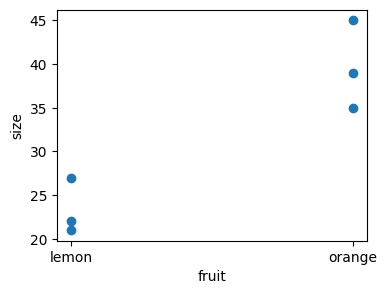

In [42]:

import matplotlib.pyplot as plt

plt.figure(figsize=(4,3))

plt.xlabel('fruit')
plt.ylabel('size')

plt.scatter(df["Fruit"], df["Size"])
plt.show()

In [43]:
# เรียกใช้งาน DecisionTree
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

In [44]:
# Define X and y 
X = df["Size"]
X.shape   #(6,)
X = df[["Size"]]
# หรือ df["Size"].values.reshape(-1, 1)
X.shape  # (6,1)

y = df["y"]   

In [45]:
# X ต้องเป็น 2  มิติ y ไม่จำเป็น 
model.fit(X, y)  # X ตัวพิมพ์ใหญ่ 

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [46]:
# สมมติว่ามี ขนาด 25  จะเป็นผลไม้อะไร (Lemon, Orange)
data = [[25]]
y_predict = model.predict(data)
print('Result =', y_predict )

Result = [0]


c:\Users\sitth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [47]:
# สร้างการแสดงผลกลับ 
class_names = ['lemon','orange']  # List 0,1 

In [48]:
data = [[25]]
y_predict = model.predict(data)

prd = class_names[y_predict[0]]
print(f'Result : {prd}' )

Result : lemon


c:\Users\sitth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [49]:
data = [[35.3]]
y_predict = model.predict(data)

prd = class_names[y_predict[0]]
print('Result : {}'. format(prd))

Result : orange


c:\Users\sitth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [50]:
# 32, 25, 21, 38 

data = [[32],
         [25],
         [21],
         [38]]

y_predict = model.predict(data)
y_predict

print('Result:')
for i in y_predict:
    print(class_names[i])

Result:
orange
lemon
lemon
orange


c:\Users\sitth\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


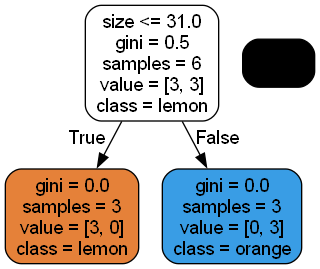

In [51]:
data_feature_names = ['size']
fruit_types = ['lemon','orange'] 

import pydotplus

from sklearn.tree import export_graphviz
from IPython.display import Image

dot_data = export_graphviz(model, out_file=None, 
                           feature_names=data_feature_names,  
                           class_names=fruit_types, # 
                           filled=True,
                           rounded=True)


graph = pydotplus.graph_from_dot_data(dot_data)  
Image(graph.create_png())

| คำอธิบาย           | ความหมาย                                                                                               |
| ------------------ | ------------------------------------------------------------------------------------------------------ |
| **size <= 31.0**   | เป็นเงื่อนไขที่ใช้แบ่งข้อมูล (split) — ถ้า `size` ≤ 31 ไปทางซ้าย (True) ถ้ามากกว่า 31 ไปทางขวา (False) |
| **gini = 0.5**     | ค่า **Gini Index** ของโหนดนี้ = 0.5 → หมายถึงความบริสุทธิ์ต่ำ (ผสมกัน 50-50)                           |
| **samples = 6**    | มีข้อมูลในโหนดนี้ทั้งหมด 6 ตัวอย่าง                                                                    |
| **value = [3, 3]** | มี 3 ตัวอย่างเป็น Lemon, 3 ตัวอย่างเป็น Orange                                                         |
| **class = lemon**  | “class ส่วนใหญ่” คือ Lemon (เพราะตอนเทรน ถ้ามีเท่ากัน มักเลือก class แรก)                              |


In [52]:
# Example 2 
X = [[27],                                                              
     [35],                                                              
     [39],                                                              
     [21],                                                              
     [22],                                                                   
     [45],
     [102],
     [110],
     [120] ]                                                              

y_names = ['lemon', 'orange', 'orange', 'lemon', 'lemon', 'orange', 'pamelo', 'pamelo', 'pamelo']
y = [0, 1, 1, 0, 0, 1, 2, 2, 2]

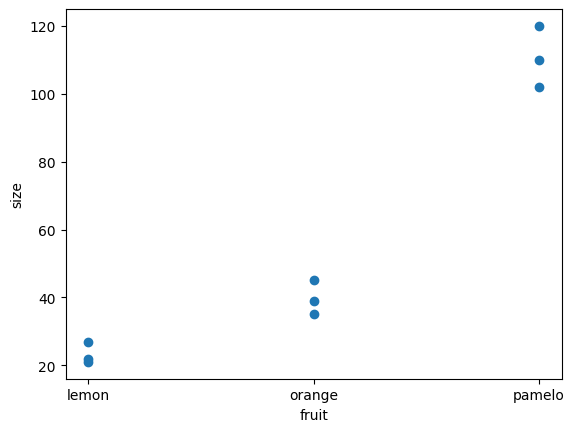

In [53]:
plt.xlabel('fruit')
plt.ylabel('size')

plt.scatter(y_names, X)
plt.show()

In [54]:
model.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
class_names = ['lemon','orange', 'pamelo']

In [ ]:
data = [[25]]
y_predict = model.predict(data)

prd = class_names[y_predict[0]]
print(f'Result : {prd}')

Result : lemon


In [ ]:
data = [[43]]
y_predict = model.predict(data)

prd = class_names[y_predict[0]]
print(f'Result : {prd}')

Result : orange


In [58]:
data = [[104]]
y_predict = model.predict(data)

prd = class_names[y_predict[0]]
print('Result : {}'. format(prd))

Result : pamelo


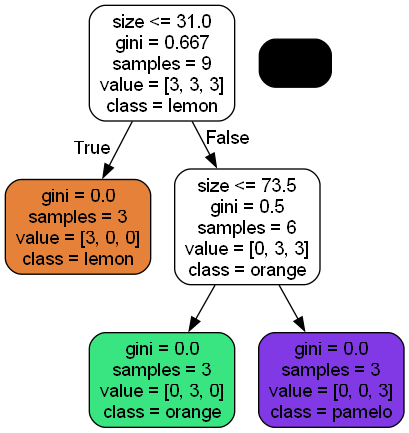

In [59]:
data_feature_names = ['size']
fruit_types = ['lemon','orange','pamelo'] 

import pydotplus

from sklearn.tree import export_graphviz
from IPython.display import Image

dot_data = export_graphviz(model, out_file=None, 
                           feature_names=data_feature_names,  
                           class_names=fruit_types, # 
                           filled=True,
                           rounded=True)


graph = pydotplus.graph_from_dot_data(dot_data)  
Image(graph.create_png())